今回使う、ライブライのimport,およびデータセットのダウンロード

In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_iris
train = pd.read_csv("train.csv") 
test=pd.read_csv("test.csv")
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


長さ確認および、基本情報、欠損地確認

In [158]:
print(len(train),len(test))
train.describe().T



891 418


,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [159]:
print(train.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


欠損値確認,age,cabin, Embarked に大きな欠損が見られる。
 Embarkedは、欠損が２なので、最頻値で埋める
ageに関しては、欠損の保管を考え、cabinに関しては、trainもtestともともに欠損が大きいので、今回のモデルでは使わない
name,PassengerIdは解析に必要ないため、削除、Ticketも法則性の観点から、削除
また、sexに関しては0,1に変更
Embarkedも0,1,2に変更
testデータも同様に（ただし、Fareに一個欠損値があるのでこれはtrainの中央値で埋める）

In [160]:
train.isna().sum(),test.isna().sum()

(PassengerId      0
 Survived         0
 Pclass           0
 Name             0
 Sex              0
 Age            177
 SibSp            0
 Parch            0
 Ticket           0
 Fare             0
 Cabin          687
 Embarked         2
 dtype: int64,
 PassengerId      0
 Pclass           0
 Name             0
 Sex              0
 Age             86
 SibSp            0
 Parch            0
 Ticket           0
 Fare             1
 Cabin          327
 Embarked         0
 dtype: int64)

In [161]:
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])

In [162]:
train.drop(columns={"PassengerId","Name","Ticket","Cabin"},inplace=True)
test.drop(columns={"PassengerId","Name","Ticket","Cabin"},inplace=True)


In [163]:
test.Fare=test.Fare.fillna(np.median(train.Fare))
test.isna().sum()

Pclass       0
Sex          0
Age         86
SibSp        0
Parch        0
Fare         0
Embarked     0
dtype: int64

In [164]:
train.Embarked=train.Embarked.map({"S":0,"C":0,"Q":0})
train.Sex=train.Sex.map({'male':0,"female":1})
test.Embarked=test.Embarked.map({"S":0,"C":0,"Q":0})
test.Sex=test.Sex.map({'male':0,"female":1})

In [165]:
train.isna().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      0
dtype: int64

In [166]:
train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,0
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


ageに関して詳しく見ていく
欠損の保管の方針としては、中央値で埋める、なにかしらの因果関係を見つけてそれに対応するように埋めるなど...
基本の確認をしながら埋めていく
年齢の分布は以下のようになっている

(array([ 54.,  46., 177., 169., 118.,  70.,  45.,  24.,   9.,   2.]),
 array([ 0.42 ,  8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126,
        64.084, 72.042, 80.   ]),
 <BarContainer object of 10 artists>)

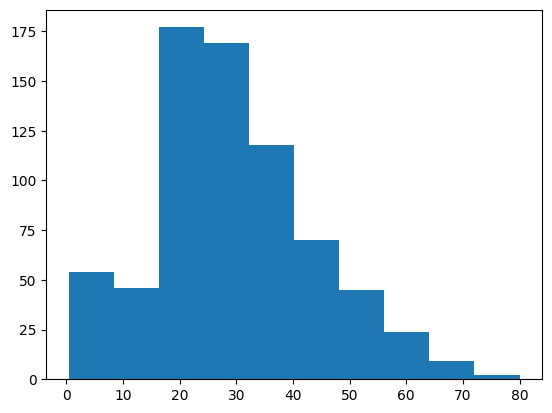

In [167]:
plt.hist(train.Age)


欠損値別、各項目を見ていく
SibSp / Parch（家族構成）が0が多く、pclassも3が多い、このことから　
pclassと、sexごとに中央値をとり、それに該当する欠損値に代入するという手法をとる

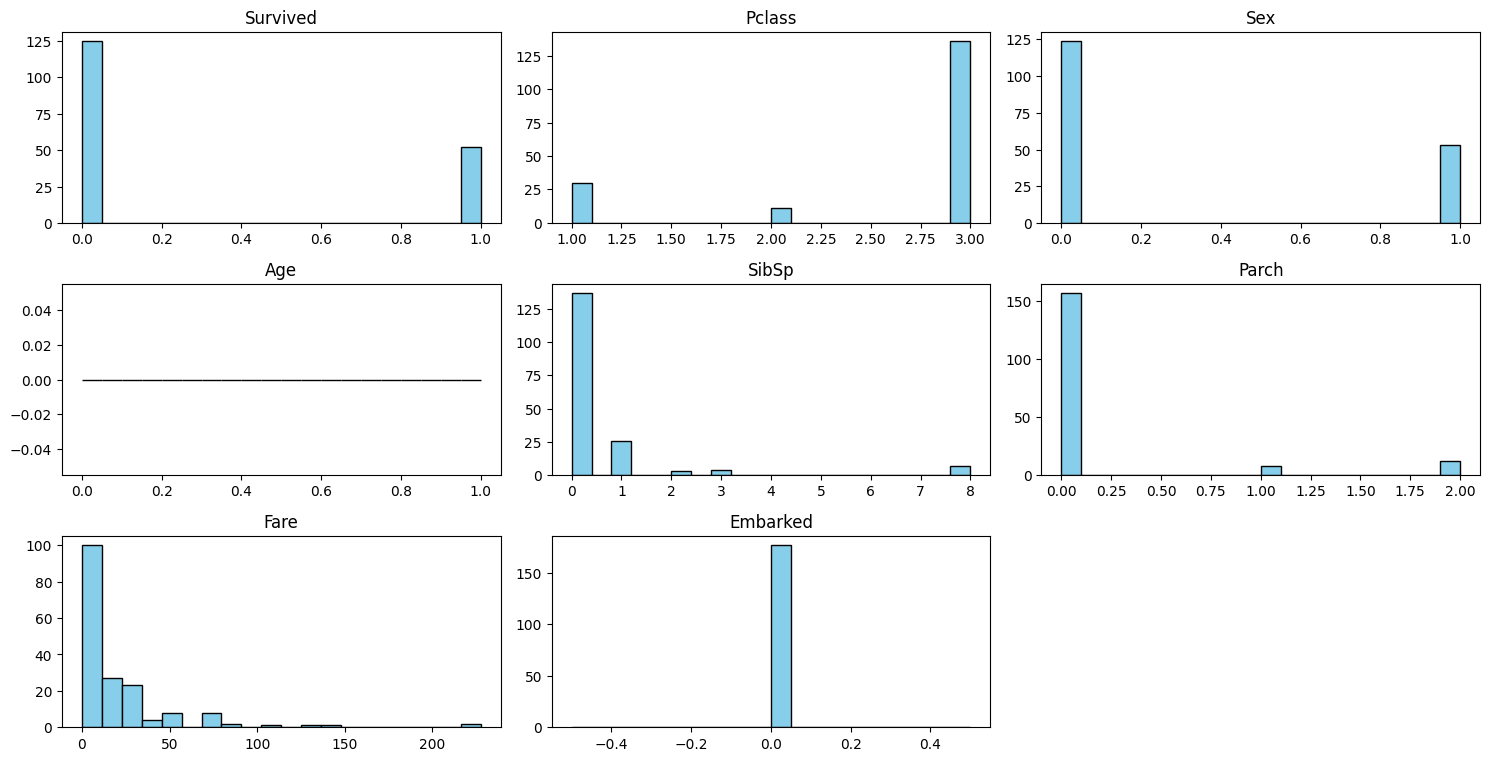

In [168]:
train_age_null=train.query("Age.isnull()")
plt.figure(figsize=(15, 10))
for i, name in enumerate(train_age_null.columns):
    if train_age_null[name].dtype in ['int64', 'float64']:
        plt.subplot(4, 3, i + 1) 
        plt.hist(train_age_null[name].dropna(), bins=20, color='skyblue', edgecolor='black')
        plt.title(name)

plt.tight_layout()
plt.show()

In [169]:
#for df in [train, test]:
#   df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
age_null = train.groupby(['Pclass', 'Sex'])['Age'].median().reset_index()
train = train.merge(age_null, on=['Pclass', 'Sex'], suffixes=('', '_median'))
test = test.merge(age_null, on=['Pclass', 'Sex'], suffixes=('', '_median'))

train['Age'] = train['Age'].fillna(train['Age_median'])
test['Age'] = test['Age'].fillna(test['Age_median'])

train = train.drop('Age_median', axis=1)
test = test.drop('Age_median', axis=1)